In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [26]:
df = pd.read_csv('data/heart_failure_readmission_dataset.csv')
df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   float64
 13  income_level             3000 non-null   str    
 14  distance_to_hospital_km  3000 non-n

In [28]:
#identifying missing values
print(df[['bmi', 'sodium', 'creatinine']].isnull().sum())
# setting median for null values
df[['bmi', 'sodium', 'creatinine']] = df[['bmi', 'sodium', 'creatinine']].fillna(df[['bmi', 'sodium', 'creatinine']].median())

bmi           90
sodium        90
creatinine    90
dtype: int64


In [29]:
print("Shape:", df.shape)
print("\nClass distribution:\n", df['readmitted_30d'].value_counts())

Shape: (3000, 16)

Class distribution:
 readmitted_30d
0    1766
1    1234
Name: count, dtype: int64


In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

In [31]:
BG      = '#0D1117'
CARD    = '#161B22'
CARD2   = '#1C2430'
ACCENT  = '#58A6FF'
GREEN   = '#3FB950'
RED     = '#F85149'
YELLOW  = '#D29922'
PURPLE  = '#BC8CFF'
ORANGE  = '#FFA657'
TEXT    = '#E6EDF3'
MUTED   = '#8B949E'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': '#30363D', 'axes.labelcolor': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': TEXT, 'grid.color': '#21262D',
    'grid.linewidth': 0.5, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})
 
PALETTE = {0: GREEN, 1: RED}

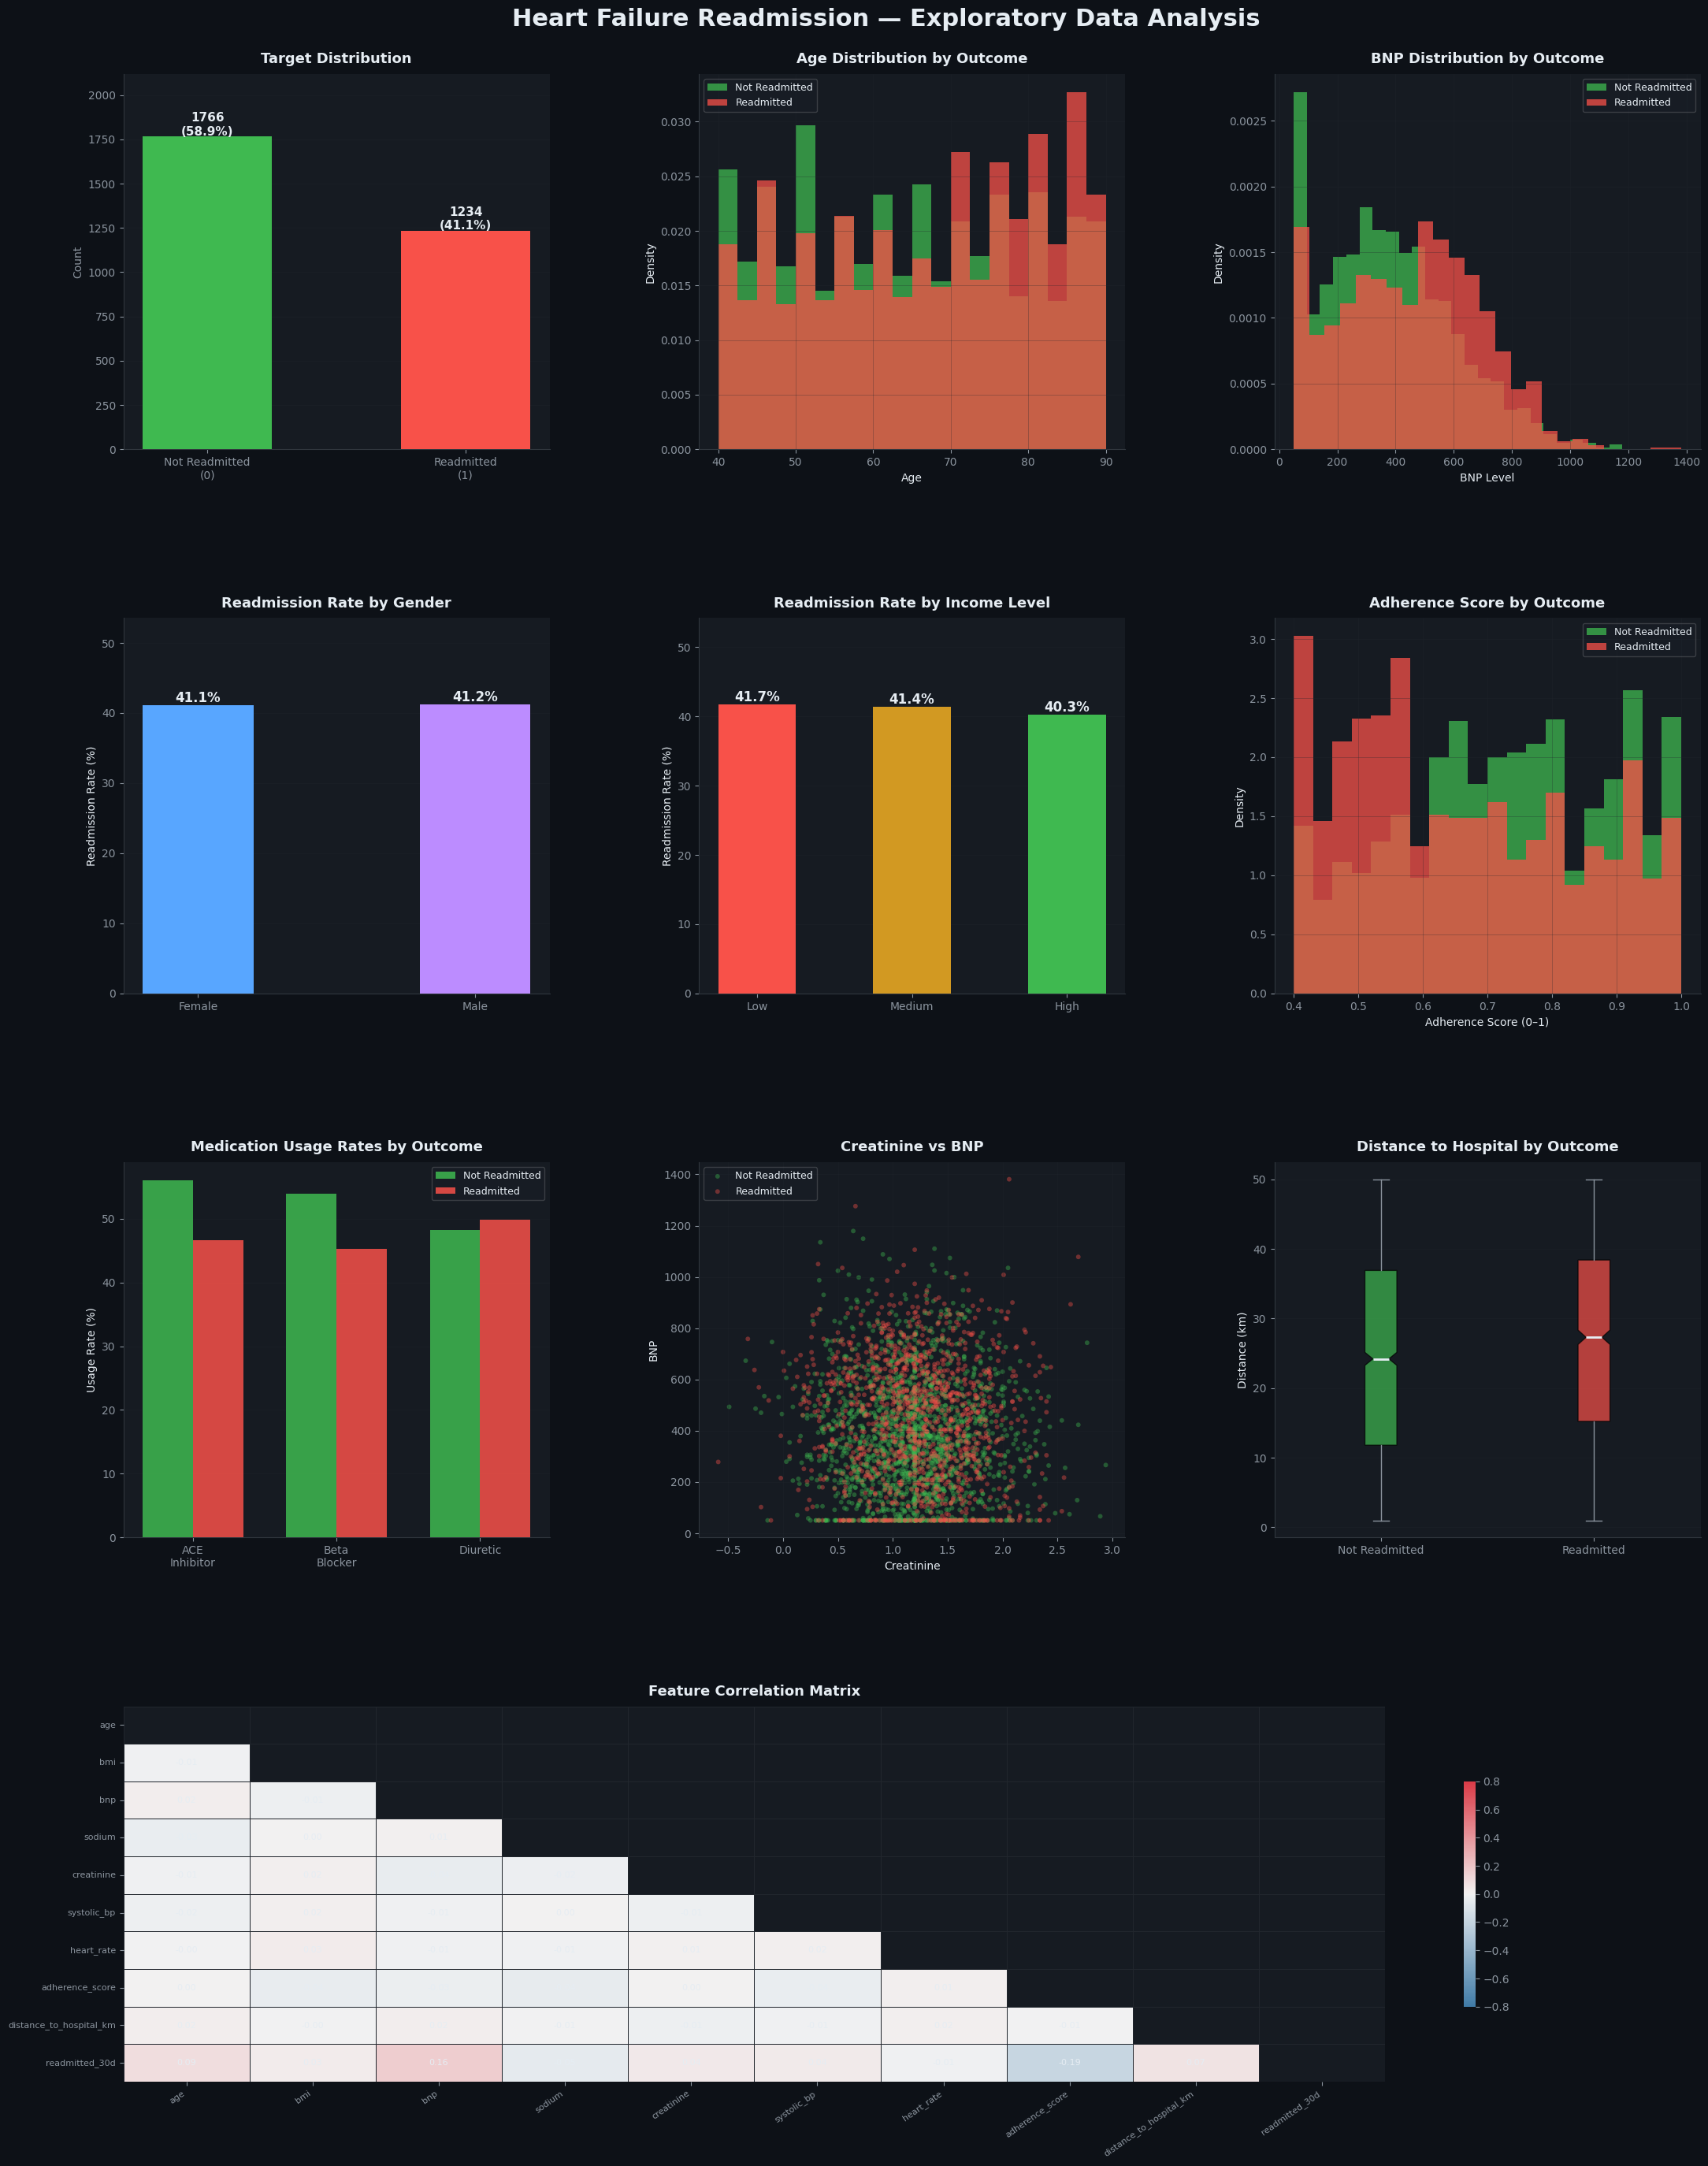

In [32]:
# FIGURE 1 — EDA Overview
# ═══════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 28), facecolor=BG)
fig1.suptitle('Heart Failure Readmission — Exploratory Data Analysis',
              fontsize=22, fontweight='bold', color=TEXT, y=0.98)
 
gs = gridspec.GridSpec(4, 3, figure=fig1, hspace=0.45, wspace=0.35,
                       top=0.95, bottom=0.04, left=0.06, right=0.97)
 
# --- 1.1 Target Distribution ---
ax = fig1.add_subplot(gs[0, 0])
counts = df['readmitted_30d'].value_counts()
bars = ax.bar(['Not Readmitted\n(0)', 'Readmitted\n(1)'],
              [counts[0], counts[1]], color=[GREEN, RED],
              width=0.5, edgecolor='none', zorder=3)
for bar, v in zip(bars, [counts[0], counts[1]]):
    pct = v / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{v}\n({pct:.1f}%)', ha='center', fontsize=11, color=TEXT, fontweight='bold')
ax.set_title('Target Distribution', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Count', color=MUTED); ax.set_ylim(0, counts[0]*1.2)
ax.grid(axis='y', alpha=0.4); ax.tick_params(labelsize=10)
 
# --- 1.2 Age Distribution by Outcome ---
ax = fig1.add_subplot(gs[0, 1])
for label, color in PALETTE.items():
    sub = df[df['readmitted_30d'] == label]['age']
    ax.hist(sub, bins=20, alpha=0.75, color=color, edgecolor='none',
            label='Readmitted' if label else 'Not Readmitted', density=True)
ax.set_title('Age Distribution by Outcome', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Age'); ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.2, facecolor=CARD2); ax.grid(alpha=0.4)

# --- 1.3 BNP Distribution by Outcome ---
ax = fig1.add_subplot(gs[0, 2])
for label, color in PALETTE.items():
    sub = df[df['readmitted_30d'] == label]['bnp']
    ax.hist(sub, bins=25, alpha=0.75, color=color, edgecolor='none',
            label='Readmitted' if label else 'Not Readmitted', density=True)
ax.set_title('BNP Distribution by Outcome', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('BNP Level'); ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.2, facecolor=CARD2); ax.grid(alpha=0.4)
 
# --- 1.4 Gender Readmission Rate ---
ax = fig1.add_subplot(gs[1, 0])
gender_rate = df.groupby('gender')['readmitted_30d'].mean() * 100
bars = ax.bar(gender_rate.index, gender_rate.values,
              color=[ACCENT, PURPLE], width=0.4, edgecolor='none', zorder=3)
for bar, v in zip(bars, gender_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=12, color=TEXT, fontweight='bold')
ax.set_title('Readmission Rate by Gender', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Readmission Rate (%)'); ax.set_ylim(0, gender_rate.max()*1.3)
ax.grid(axis='y', alpha=0.4)
 
# --- 1.5 Income Level Readmission ---
ax = fig1.add_subplot(gs[1, 1])
order = ['Low', 'Medium', 'High']
income_rate = df.groupby('income_level')['readmitted_30d'].mean().reindex(order) * 100
colors_inc = [RED, YELLOW, GREEN]
bars = ax.bar(order, income_rate.values, color=colors_inc, width=0.5, edgecolor='none', zorder=3)
for bar, v in zip(bars, income_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=12, color=TEXT, fontweight='bold')
ax.set_title('Readmission Rate by Income Level', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Readmission Rate (%)'); ax.set_ylim(0, income_rate.max()*1.3)
ax.grid(axis='y', alpha=0.4)
 
# --- 1.6 Medication Adherence ---
ax = fig1.add_subplot(gs[1, 2])
for label, color in PALETTE.items():
    sub = df[df['readmitted_30d'] == label]['adherence_score']
    ax.hist(sub, bins=20, alpha=0.75, color=color, edgecolor='none',
            label='Readmitted' if label else 'Not Readmitted', density=True)
ax.set_title('Adherence Score by Outcome', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Adherence Score (0–1)'); ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.2, facecolor=CARD2); ax.grid(alpha=0.4)
 
# --- 1.7 Medication Usage Rates ---
ax = fig1.add_subplot(gs[2, 0])
meds = ['ace_inhibitor', 'beta_blocker', 'diuretic']
med_labels = ['ACE\nInhibitor', 'Beta\nBlocker', 'Diuretic']
x = np.arange(len(meds))
w = 0.35
for i, (label, color) in enumerate(PALETTE.items()):
    sub = df[df['readmitted_30d'] == label]
    rates = [sub[m].mean()*100 for m in meds]
    bars = ax.bar(x + i*w - w/2, rates, w, color=color, alpha=0.85, edgecolor='none',
                  label='Readmitted' if label else 'Not Readmitted', zorder=3)
ax.set_xticks(x); ax.set_xticklabels(med_labels, fontsize=10)
ax.set_title('Medication Usage Rates by Outcome', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Usage Rate (%)'); ax.legend(fontsize=9, framealpha=0.2, facecolor=CARD2)
ax.grid(axis='y', alpha=0.4)
 
# --- 1.8 Creatinine vs BNP Scatter ---
ax = fig1.add_subplot(gs[2, 1])
for label, color in PALETTE.items():
    sub = df[df['readmitted_30d'] == label]
    ax.scatter(sub['creatinine'], sub['bnp'], c=color, alpha=0.4, s=18,
               label='Readmitted' if label else 'Not Readmitted', edgecolors='none')
ax.set_title('Creatinine vs BNP', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Creatinine'); ax.set_ylabel('BNP')
ax.legend(fontsize=9, framealpha=0.2, facecolor=CARD2); ax.grid(alpha=0.4)
 
# --- 1.9 Distance to Hospital Box ---
ax = fig1.add_subplot(gs[2, 2])
data_box = [df[df['readmitted_30d']==0]['distance_to_hospital_km'],
            df[df['readmitted_30d']==1]['distance_to_hospital_km']]
bp = ax.boxplot(data_box, patch_artist=True, notch=True,
                medianprops={'color': TEXT, 'linewidth': 2},
                whiskerprops={'color': MUTED}, capprops={'color': MUTED},
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3})
for patch, color in zip(bp['boxes'], [GREEN, RED]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticklabels(['Not Readmitted', 'Readmitted'])
ax.set_title('Distance to Hospital by Outcome', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Distance (km)'); ax.grid(axis='y', alpha=0.4)
 
# --- 1.10 Correlation Heatmap ---
ax = fig1.add_subplot(gs[3, :])
num_features = ['age','bmi','bnp','sodium','creatinine','systolic_bp',
                'heart_rate','adherence_score','distance_to_hospital_km','readmitted_30d']
corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#21262D',
            ax=ax, annot_kws={'size': 8, 'color': TEXT},
            cbar_kws={'shrink': 0.6})
ax.set_facecolor(CARD)
ax.set_title('Feature Correlation Matrix', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.tick_params(labelsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.show()
plt.close()

In [35]:
# Encode Gender using Label Encoding
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

In [36]:
print(df.income_level.unique())
# Ordinal encoding for Income Level
income_order = {'Low': 0, 'Medium': 1, 'High': 2}
df['income_encoded'] = df['income_level'].map(income_order)

print(df.head())

<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
   patient_id  age  gender   bmi  bnp  sodium  creatinine  systolic_bp  \
0       12911   76    Male  23.9  738   135.3        1.58          151   
1       12521   77    Male  32.3  405   143.0        1.50          107   
2       10155   42    Male  29.3  399   138.1        1.43          121   
3       12088   83  Female  29.1  524   135.1        0.91          114   
4       10792   48  Female  24.2  301   139.5        0.54          122   

   heart_rate  ace_inhibitor  beta_blocker  diuretic  adherence_score  \
0          93              1             1         0             0.98   
1          74              1             0         1             0.66   
2          97              1             0         1             0.93   
3          66              0             1         1             0.54   
4          79              1             1         1             0.78   

  income_level  distance_to_hospital_km  readmitted_30

In [42]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score)
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [41]:
df_ml = df.copy()
feature_cols = ['age','bmi','bnp','sodium','creatinine','systolic_bp','heart_rate',
                'ace_inhibitor','beta_blocker','diuretic','adherence_score',
                'distance_to_hospital_km','gender_encoded','income_encoded']
 
imputer = SimpleImputer(strategy="median")
X_raw = df_ml[feature_cols]
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols)
y = df_ml['readmitted_30d']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4,
                                                     random_state=99, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
 

Testing  accuracy: 0.655


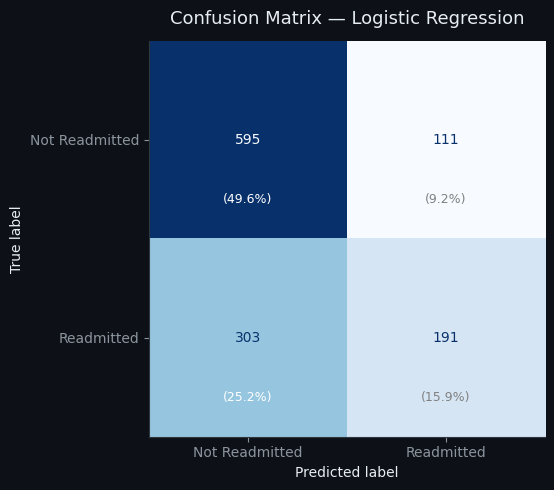

In [ ]:
log_reg_classifier = LogisticRegression()
log_reg_classifier.fit(X_train_sc, y_train)

y_pred = log_reg_classifier.predict(X_test_sc)
y_prob = log_reg_classifier.predict_proba(X_test_sc)[:, 1]
accuracy = np.mean(y_pred == y_test)
print(f"Testing  accuracy: {accuracy:.3f}")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

# Annotate with rates (optional but useful)
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.3, f"({pct:.1f}%)", ha='center', va='center',
                fontsize=9, color='white' if cm[i, j] > cm.max()/2 else 'gray')

plt.title("Confusion Matrix — Logistic Regression", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

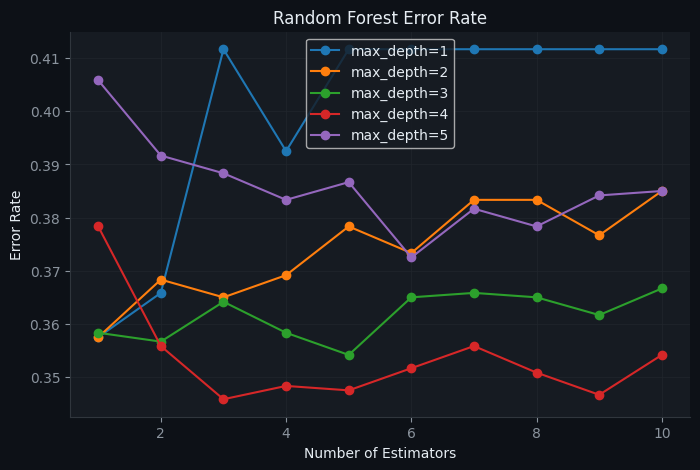

Best params -> N=3, d=4, error=0.3458, accuracy=0.6542
Testing accuracy: 0.6541666666666667


In [ ]:
subtrees_num=np.arange(1, 11)
depths=np.arange(3, 13)
results = []
for n in subtrees_num:
    for d in depths:
        model = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=99)
        model.fit(X_train, y_train)
        predicted = model.predict(X_test)
        err_rate = np.mean(predicted != y_test)
        results.append((n, d, err_rate))
        
        
results_df = pd.DataFrame(results, columns=['n_estimators', 'max_depth', 'error_rate'])
plt.figure(figsize=(8,5))
for d in depths:
    subset = results_df[results_df['max_depth'] == d].sort_values('n_estimators')
    plt.plot(subset['n_estimators'], subset['error_rate'], marker='o', label=f'max_depth={d}')
plt.xlabel('Number of Estimators')
plt.ylabel('Error Rate')
plt.title('Random Forest Error Rate')
plt.legend()
plt.grid()
plt.show()

best = results_df.sort_values(['error_rate','n_estimators','max_depth'], ascending=[True, False, True]).iloc[0]
best_N, best_d = int(best.n_estimators), int(best.max_depth)
print(f"Best params -> N={best_N}, d={best_d}, error={best.error_rate:.4f}, accuracy={1-best.error_rate:.4f}")

rf_classifier = RandomForestClassifier(n_estimators=best_N, max_depth=best_d, criterion='gini', random_state=79)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Testing accuracy: {accuracy}")

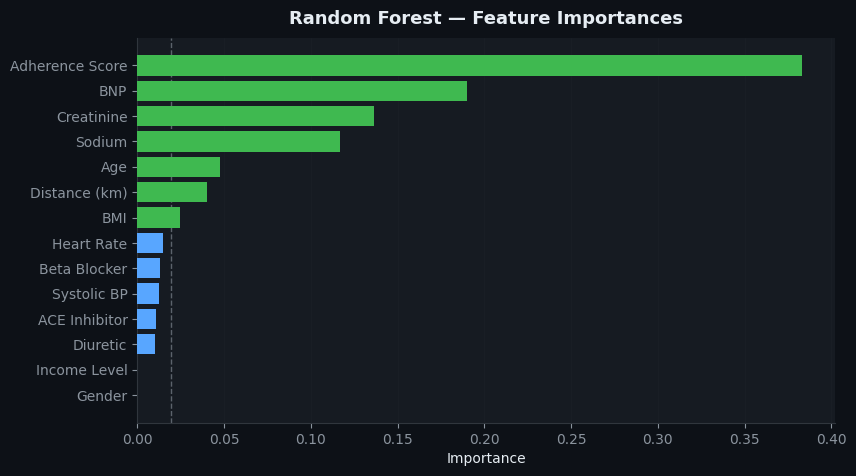

In [58]:
# Feature importances (RF)
fi = pd.Series(rf_classifier.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_labels = ['Age','BMI','BNP','Sodium','Creatinine','Systolic BP','Heart Rate',
               'ACE Inhibitor','Beta Blocker','Diuretic','Adherence Score',
               'Distance (km)','Gender','Income Level']
fi_labeled = pd.Series(rf_classifier.feature_importances_, index=feat_labels).sort_values()
colors_fi = [GREEN if v > fi_labeled.median() else ACCENT for v in fi_labeled]
ax.barh(fi_labeled.index, fi_labeled.values, color=colors_fi, edgecolor='none', zorder=3)
ax.set_title('Random Forest — Feature Importances', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.4)
ax.axvline(fi_labeled.median(), color=MUTED, linestyle='--', linewidth=1, alpha=0.6)
 

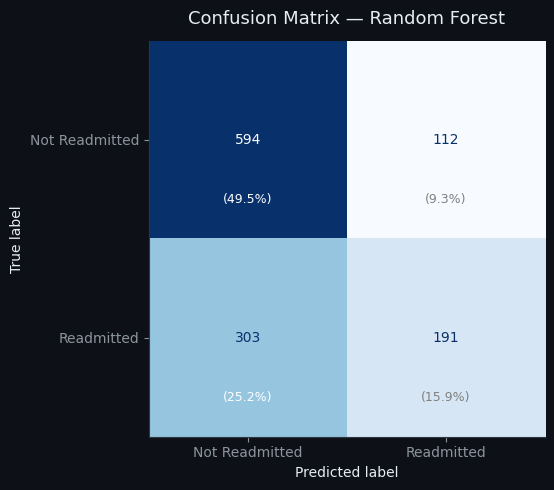

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

# Annotate with rates (optional but useful)
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.3, f"({pct:.1f}%)", ha='center', va='center',
                fontsize=9, color='white' if cm[i, j] > cm.max()/2 else 'gray')

plt.title("Confusion Matrix — Random Forest", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

Testing accuracy: 0.660


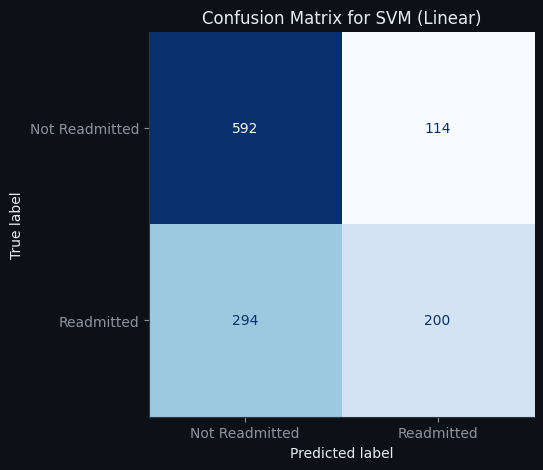

In [56]:
from sklearn import svm

svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)
accuracy = np.mean(y_pred==y_test)
print(f"Testing accuracy: {accuracy:.3f}")


cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Confusion Matrix for SVM (Linear)")
plt.show()

In [45]:
# ─── TRAIN MODELS ───────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                     max_depth=4, random_state=42),
}
 
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    cv_scores = cross_val_score(model,
                                X_train_sc if name=='Logistic Regression' else X_train,
                                y_train, cv=cv, scoring='roc_auc')
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'auc': auc, 'ap': ap,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }
    print(f"{name}: AUC={auc:.3f}, CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")
 
# Feature importances (RF)
rf = models['Random Forest']
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
 

Logistic Regression: AUC=0.691, CV=0.667±0.042
Random Forest: AUC=0.688, CV=0.673±0.026
Gradient Boosting: AUC=0.657, CV=0.643±0.024
